In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

df = pd.read_csv(data)

df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [3]:
df.shape

(5000, 9)

In [4]:
# check for missing values

df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [5]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [6]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [7]:
categorical_columns = []
numerical_columns = []

for i in df.columns:
    if df[i].dtypes == 'str':
        categorical = categorical_columns.append(i)
    if df[i].dtypes != 'str':
        numerical = numerical_columns.append(i)
    

In [8]:
categorical_columns

['lead_source', 'industry', 'employment_status', 'location']

In [9]:
numerical_columns

['annual_income',
 'number_of_courses_viewed',
 'interaction_count',
 'lead_score',
 'converted']

In [10]:
df[numerical_columns] = df[numerical_columns].fillna(0.0)

df[numerical_columns].isnull().sum()

annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [11]:
df[categorical_columns] = df[categorical_columns].fillna('NA')

df[categorical_columns].isnull().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [12]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [13]:
df_full = df[numerical_columns + categorical_columns]

df_full.columns 

Index(['annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted', 'lead_source', 'industry',
       'employment_status', 'location'],
      dtype='str')

In [14]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [15]:
columns = ['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted']

df_full = df_full[columns]

df_full.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [16]:
df_full.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [17]:
df_full['industry'].mode()[0]

'technology'

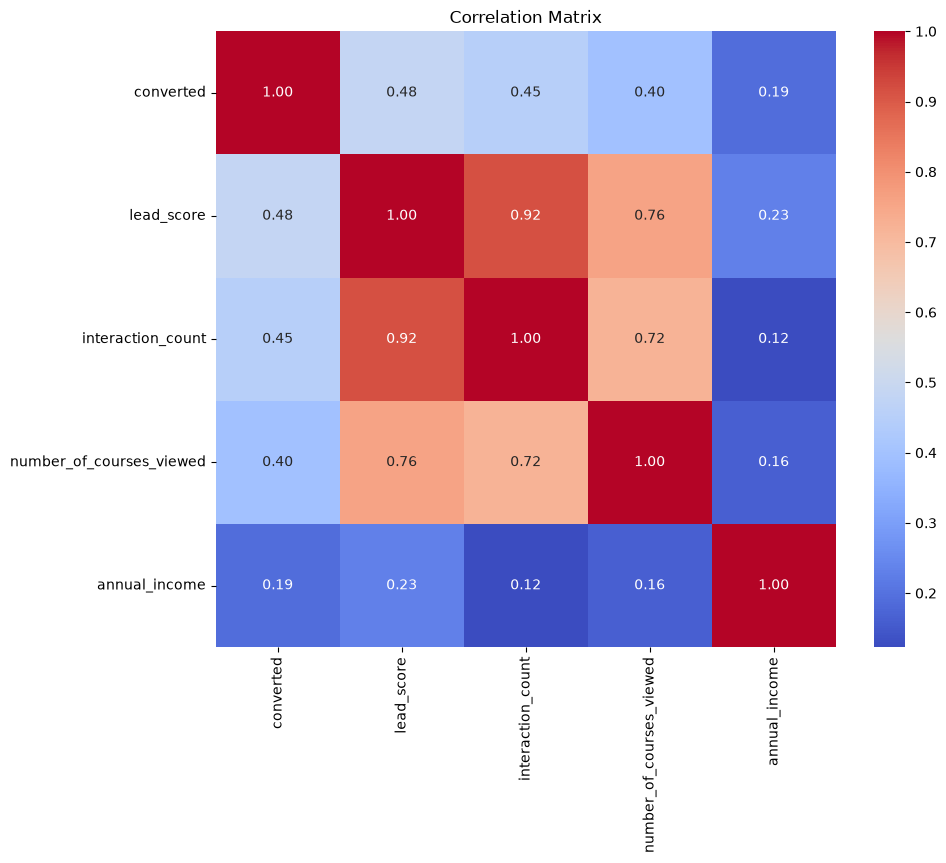

In [18]:
corr_matrix = df_full[numerical_columns].corr()

order = corr_matrix['converted'].sort_values(ascending=False).index

corr_matrix_order = corr_matrix.loc[order, order]

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix_order,
            annot=True,
            fmt='.2f',
            cmap='coolwarm'
           )
plt.title('Correlation Matrix')
plt.show()

In [19]:
# Split the dataset
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df_full, test_size = 0.2, random_state=42)

df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [20]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [21]:
len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [22]:
y_train = df_train['converted'].values
y_train

array([1, 0, 1, ..., 1, 0, 0], shape=(3000,))

In [23]:
y_val = df_val['converted'].values
y_test = df_test['converted'].values

In [24]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

In [25]:
df_full_train[categorical_columns].nunique()

lead_source          6
industry             7
employment_status    5
location             6
dtype: int64

In [26]:
from sklearn.metrics import mutual_info_score

mutual_info_score(df_full_train['converted'], df_full_train['lead_source'])

0.0347609795100606

In [27]:
def mutual_info_converted_score(series):
    return mutual_info_score(series, df_full_train['converted'])

In [28]:
mi = df_full_train[categorical_columns].apply(mutual_info_converted_score)
mi.sort_values(ascending=False).round(2)

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64

## Train a Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

In [30]:
df_train.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,finance,employed,asia,65980.0,2,3,0.37
1,events,finance,employed,south_america,71662.0,0,0,0.09
2,referral,NA,employed,asia,40220.0,2,5,0.55
3,organic_search,finance,employed,north_america,88352.0,2,2,0.45
4,events,technology,employed,north_america,89316.0,1,5,0.00


In [31]:
dv = DictVectorizer(sparse=False)

train_dicts = df_train.to_dict(orient='records')
train_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37}

In [32]:
X_train = dv.fit_transform(train_dicts)

X_train.shape

(3000, 28)

In [33]:
val_dicts = df_val.to_dict(orient='records')

X_val = dv.transform(val_dicts)
X_val.shape

(1000, 28)

In [34]:
X_train.shape, y_train.shape

((3000, 28), (3000,))

In [35]:
model = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [36]:
accuracy_score = model.score(X_val, y_val)
print(round(accuracy_score, 2))

0.65


In [37]:
accuracy_score = model.score(X_val, y_val)
print(accuracy_score)

0.645


In [38]:
X_train

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 28))

In [39]:
df_train.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,finance,employed,asia,65980.0,2,3,0.37
1,events,finance,employed,south_america,71662.0,0,0,0.09
2,referral,NA,employed,asia,40220.0,2,5,0.55
3,organic_search,finance,employed,north_america,88352.0,2,2,0.45
4,events,technology,employed,north_america,89316.0,1,5,0.00


In [40]:
df_train.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score'],
      dtype='str')

In [41]:
features = ['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score']

for feature in features:
    subset = [f for f in features if f != feature]

    print('Removing:', feature)
    print('using:', subset)

Removing: lead_source
using: ['industry', 'employment_status', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
Removing: industry
using: ['lead_source', 'employment_status', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
Removing: employment_status
using: ['lead_source', 'industry', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
Removing: location
using: ['lead_source', 'industry', 'employment_status', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
Removing: annual_income
using: ['lead_source', 'industry', 'employment_status', 'location', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
Removing: number_of_courses_viewed
using: ['lead_source', 'industry', 'employment_status', 'location', 'annual_income', 'interaction_count', 'lead_score']
Removing: interaction_count
using: ['lead_source', 'industry', 'employ

In [42]:
Removing_lead_source = ['industry', 'employment_status', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

df_removing_lead_source = df_train[Removing_lead_source]

df_removing_lead_source.head()

,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,finance,employed,asia,65980.0,2,3,0.37
1,finance,employed,south_america,71662.0,0,0,0.09
2,NA,employed,asia,40220.0,2,5,0.55
3,finance,employed,north_america,88352.0,2,2,0.45
4,technology,employed,north_america,89316.0,1,5,0.00


In [43]:
df_removing_lead_source_dicts = df_removing_lead_source.to_dict(orient='records')
df_removing_lead_source_dicts[0]

{'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37}

In [44]:
X_train_removing_lead_source = dv.fit_transform(df_removing_lead_source_dicts)
X_train_removing_lead_source

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 22))

In [45]:
model_removing_lead_source = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_lead_source.fit(X_train_removing_lead_source, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [46]:
df_val_removing_lead_source = df_val[Removing_lead_source]

df_val_removing_lead_source.head()

,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,technology,employed,asia,80457.0,3,5,0.64
1,NA,self_employed,africa,74480.0,0,1,0.26
2,technology,student,africa,43944.0,2,4,0.49
3,finance,employed,europe,73795.0,2,6,0.68
4,finance,NA,north_america,76619.0,1,3,0.40


In [47]:
df_val_removing_lead_source_dicts = df_val_removing_lead_source.to_dict(orient='records')
df_val_removing_lead_source_dicts[0]

{'industry': 'technology',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64}

In [48]:
X_val_removing_lead_source = dv.transform(df_val_removing_lead_source_dicts)
X_val_removing_lead_source

array([[8.0457e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [7.4480e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.3944e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [6.2439e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0878e+04, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.8769e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00]], shape=(1000, 22))

In [49]:
accuracy_score_without_lead_source = model_removing_lead_source.score(X_val_removing_lead_source, y_val)

accuracy_score_without_lead_source

0.642

In [50]:
Removing_industry = ['lead_source', 'employment_status', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

df_removing_industry = df_train[Removing_industry]

df_removing_industry.head()

,lead_source,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,employed,asia,65980.0,2,3,0.37
1,events,employed,south_america,71662.0,0,0,0.09
2,referral,employed,asia,40220.0,2,5,0.55
3,organic_search,employed,north_america,88352.0,2,2,0.45
4,events,employed,north_america,89316.0,1,5,0.00


In [51]:
df_removing_industry_dicts = df_removing_industry.to_dict(orient='records')

df_removing_industry_dicts[0]

{'lead_source': 'paid_ads',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37}

In [52]:
X_train_removing_industry = dv.fit_transform(df_removing_industry_dicts)

X_train_removing_industry

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 21))

In [53]:
df_val_removing_industry = df_val[Removing_industry]

df_val_removing_industry.head()

,lead_source,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,NA,employed,asia,80457.0,3,5,0.64
1,events,self_employed,africa,74480.0,0,1,0.26
2,paid_ads,student,africa,43944.0,2,4,0.49
3,organic_search,employed,europe,73795.0,2,6,0.68
4,paid_ads,NA,north_america,76619.0,1,3,0.40


In [54]:
df_val_removing_industry_dicts = df_val_removing_industry.to_dict(orient='records')

df_val_removing_industry_dicts[0]

{'lead_source': 'NA',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64}

In [55]:
X_val_removing_industry = dv.transform(df_val_removing_industry_dicts)

X_val_removing_industry

array([[8.0457e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [7.4480e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.3944e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [6.2439e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0878e+04, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.8769e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00]], shape=(1000, 21))

In [56]:
model_removing_industry = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_industry.fit(X_train_removing_industry, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [57]:
accuracy_score_without_industry = model_removing_industry.score(X_val_removing_industry, y_val)

accuracy_score_without_industry

0.645

In [58]:
Removing_employment_status = ['lead_source', 'industry', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

df_removing_employment_status = df_train[Removing_employment_status]

df_removing_employment_status.head()

,lead_source,industry,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,finance,asia,65980.0,2,3,0.37
1,events,finance,south_america,71662.0,0,0,0.09
2,referral,NA,asia,40220.0,2,5,0.55
3,organic_search,finance,north_america,88352.0,2,2,0.45
4,events,technology,north_america,89316.0,1,5,0.00


In [59]:
df_removing_employment_status_dicts = df_removing_employment_status.to_dict(orient='records')

df_removing_employment_status_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'location': 'asia',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37}

In [60]:
X_train_removing_employment_status = dv.fit_transform(df_removing_employment_status_dicts)

X_train_removing_employment_status

array([[6.5980e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 23))

In [61]:
df_val_removing_employment_status = df_val[Removing_employment_status]

df_val_removing_employment_status.head()

,lead_source,industry,location,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,NA,technology,asia,80457.0,3,5,0.64
1,events,NA,africa,74480.0,0,1,0.26
2,paid_ads,technology,africa,43944.0,2,4,0.49
3,organic_search,finance,europe,73795.0,2,6,0.68
4,paid_ads,finance,north_america,76619.0,1,3,0.40


In [62]:
df_val_removing_employment_status_dicts = df_val_removing_employment_status.to_dict(orient='records')

df_val_removing_employment_status_dicts[0]

{'lead_source': 'NA',
 'industry': 'technology',
 'location': 'asia',
 'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64}

In [63]:
X_val_removing_employment_status = dv.transform(df_val_removing_employment_status_dicts)

X_val_removing_employment_status

array([[8.0457e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [7.4480e+04, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.3944e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [6.2439e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0878e+04, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.8769e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00]], shape=(1000, 23))

In [64]:
model_removing_employment_status = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_employment_status.fit(X_train_removing_employment_status, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [65]:
accuracy_score_without_employment_status = model_removing_employment_status.score(X_val_removing_employment_status, y_val)

accuracy_score_without_employment_status

0.645

In [66]:
Removing_location = ['lead_source', 'industry', 'employment_status', 'annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

df_removing_location = df_train[Removing_location]

df_removing_location.head()

,lead_source,industry,employment_status,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,finance,employed,65980.0,2,3,0.37
1,events,finance,employed,71662.0,0,0,0.09
2,referral,NA,employed,40220.0,2,5,0.55
3,organic_search,finance,employed,88352.0,2,2,0.45
4,events,technology,employed,89316.0,1,5,0.00


In [67]:
df_removing_location_dicts = df_removing_location.to_dict(orient='records')

df_removing_location_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37}

In [68]:
X_train_removing_location = dv.fit_transform(df_removing_location_dicts)

X_train_removing_location

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 22))

In [69]:
df_val_removing_location = df_val[Removing_location]

df_val_removing_location.head()

,lead_source,industry,employment_status,annual_income,number_of_courses_viewed,interaction_count,lead_score
0,NA,technology,employed,80457.0,3,5,0.64
1,events,NA,self_employed,74480.0,0,1,0.26
2,paid_ads,technology,student,43944.0,2,4,0.49
3,organic_search,finance,employed,73795.0,2,6,0.68
4,paid_ads,finance,NA,76619.0,1,3,0.40


In [70]:
df_val_removing_location_dicts = df_val_removing_location.to_dict(orient='records')

df_val_removing_location_dicts[0]

{'lead_source': 'NA',
 'industry': 'technology',
 'employment_status': 'employed',
 'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64}

In [71]:
X_val_removing_location = dv.transform(df_val_removing_location_dicts)

X_val_removing_location

array([[8.0457e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [7.4480e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.3944e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [6.2439e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0878e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.8769e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00]], shape=(1000, 22))

In [72]:
model_removing_location = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_location.fit(X_train_removing_location, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [73]:
accuracy_score_without_location = model_removing_location.score(X_val_removing_location, y_val)

accuracy_score_without_location

0.645

In [74]:
Removing_annual_income = ['lead_source', 'industry', 'employment_status', 'location', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

df_removing_annual_income = df_train[Removing_annual_income]

df_removing_annual_income.head()

,lead_source,industry,employment_status,location,number_of_courses_viewed,interaction_count,lead_score
0,paid_ads,finance,employed,asia,2,3,0.37
1,events,finance,employed,south_america,0,0,0.09
2,referral,NA,employed,asia,2,5,0.55
3,organic_search,finance,employed,north_america,2,2,0.45
4,events,technology,employed,north_america,1,5,0.00


In [75]:
df_removing_annual_income_dicts = df_removing_annual_income.to_dict(orient='records')

df_removing_annual_income_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia',
 'number_of_courses_viewed': 2,
 'interaction_count': 3,
 'lead_score': 0.37}

In [76]:
X_train_removing_annual_income = dv.fit_transform(df_removing_annual_income_dicts)

X_train_removing_annual_income

array([[0., 1., 0., ..., 0., 0., 2.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 2.],
       ...,
       [0., 1., 0., ..., 0., 0., 3.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(3000, 27))

In [77]:
df_val_removing_annual_income = df_val[Removing_annual_income]

df_val_removing_annual_income.head()

,lead_source,industry,employment_status,location,number_of_courses_viewed,interaction_count,lead_score
0,NA,technology,employed,asia,3,5,0.64
1,events,NA,self_employed,africa,0,1,0.26
2,paid_ads,technology,student,africa,2,4,0.49
3,organic_search,finance,employed,europe,2,6,0.68
4,paid_ads,finance,NA,north_america,1,3,0.40


In [78]:
df_val_removing_annual_income_dicts = df_val_removing_annual_income.to_dict(orient='records')

df_val_removing_annual_income_dicts[0]

{'lead_source': 'NA',
 'industry': 'technology',
 'employment_status': 'employed',
 'location': 'asia',
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64}

In [79]:
X_val_removing_annual_income = dv.transform(df_val_removing_annual_income_dicts)

X_val_removing_annual_income

array([[0., 1., 0., ..., 0., 0., 3.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 2.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 1., 0., ..., 0., 0., 3.]], shape=(1000, 27))

In [80]:
model_removing_annual_income = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_annual_income.fit(X_train_removing_annual_income, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [81]:
accuracy_score_without_annual_income = model_removing_annual_income.score(X_val_removing_annual_income, y_val)

accuracy_score_without_annual_income

0.724

In [82]:
Removing_number_of_courses_viewed = ['lead_source', 'industry', 'employment_status', 'location', 'annual_income', 'interaction_count', 'lead_score']

df_removing_number_of_courses_viewed = df_train[Removing_number_of_courses_viewed]

df_removing_number_of_courses_viewed.head()

,lead_source,industry,employment_status,location,annual_income,interaction_count,lead_score
0,paid_ads,finance,employed,asia,65980.0,3,0.37
1,events,finance,employed,south_america,71662.0,0,0.09
2,referral,NA,employed,asia,40220.0,5,0.55
3,organic_search,finance,employed,north_america,88352.0,2,0.45
4,events,technology,employed,north_america,89316.0,5,0.00


In [83]:
df_removing_number_of_courses_viewed_dicts = df_removing_number_of_courses_viewed.to_dict(orient='records')

df_removing_number_of_courses_viewed_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 65980.0,
 'interaction_count': 3,
 'lead_score': 0.37}

In [84]:
X_train_removing_number_of_courses_viewed = dv.fit_transform(df_removing_number_of_courses_viewed_dicts)

X_train_removing_number_of_courses_viewed

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 27))

In [85]:
df_val_removing_number_of_courses_viewed = df_val[Removing_annual_income]

df_val_removing_number_of_courses_viewed.head()

,lead_source,industry,employment_status,location,number_of_courses_viewed,interaction_count,lead_score
0,NA,technology,employed,asia,3,5,0.64
1,events,NA,self_employed,africa,0,1,0.26
2,paid_ads,technology,student,africa,2,4,0.49
3,organic_search,finance,employed,europe,2,6,0.68
4,paid_ads,finance,NA,north_america,1,3,0.40


In [86]:
df_val_removing_number_of_courses_viewed_dicts = df_val_removing_number_of_courses_viewed.to_dict(orient='records')

df_val_removing_number_of_courses_viewed_dicts[0]

{'lead_source': 'NA',
 'industry': 'technology',
 'employment_status': 'employed',
 'location': 'asia',
 'number_of_courses_viewed': 3,
 'interaction_count': 5,
 'lead_score': 0.64}

In [87]:
X_val_removing_number_of_courses_viewed = dv.transform(df_val_removing_number_of_courses_viewed_dicts)

X_val_removing_number_of_courses_viewed

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(1000, 27))

In [88]:
model_removing_number_of_courses_viewed = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_number_of_courses_viewed.fit(X_train_removing_number_of_courses_viewed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [89]:
accuracy_score_without_number_of_courses_viewed = model_removing_number_of_courses_viewed.score(X_val_removing_number_of_courses_viewed, y_val)

accuracy_score_without_number_of_courses_viewed

0.638

In [90]:
Removing_interaction_count = ['lead_source', 'industry', 'employment_status', 'location', 'annual_income', 'number_of_courses_viewed', 'lead_score']

df_removing_interaction_count = df_train[Removing_interaction_count]

df_removing_interaction_count.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,lead_score
0,paid_ads,finance,employed,asia,65980.0,2,0.37
1,events,finance,employed,south_america,71662.0,0,0.09
2,referral,NA,employed,asia,40220.0,2,0.55
3,organic_search,finance,employed,north_america,88352.0,2,0.45
4,events,technology,employed,north_america,89316.0,1,0.00


In [91]:
df_removing_interaction_count_dicts = df_removing_interaction_count.to_dict(orient='records')

df_removing_interaction_count_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'lead_score': 0.37}

In [92]:
X_train_removing_interaction_count = dv.fit_transform(df_removing_interaction_count_dicts)

X_train_removing_interaction_count

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 27))

In [93]:
df_val_removing_interaction_count = df_val[Removing_interaction_count]

df_val_removing_interaction_count.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,lead_score
0,NA,technology,employed,asia,80457.0,3,0.64
1,events,NA,self_employed,africa,74480.0,0,0.26
2,paid_ads,technology,student,africa,43944.0,2,0.49
3,organic_search,finance,employed,europe,73795.0,2,0.68
4,paid_ads,finance,NA,north_america,76619.0,1,0.40


In [94]:
df_val_removing_interaction_count_dicts = df_val_removing_interaction_count.to_dict(orient='records')

df_val_removing_interaction_count_dicts[0]

{'lead_source': 'NA',
 'industry': 'technology',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'lead_score': 0.64}

In [95]:
X_val_removing_interaction_count = dv.transform(df_val_removing_interaction_count_dicts)

X_val_removing_interaction_count

array([[8.0457e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [7.4480e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.3944e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [6.2439e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0878e+04, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.8769e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00]], shape=(1000, 27))

In [96]:
model_removing_interaction_count = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_interaction_count.fit(X_train_removing_interaction_count, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [97]:
accuracy_score_without_interaction_count = model_removing_interaction_count.score(X_val_removing_interaction_count, y_val)
accuracy_score_without_interaction_count

0.601

In [98]:
Removing_lead_score = ['lead_source', 'industry', 'employment_status', 'location', 'annual_income', 'number_of_courses_viewed', 'interaction_count']

df_removing_lead_score = df_train[Removing_lead_score]

df_removing_lead_score.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count
0,paid_ads,finance,employed,asia,65980.0,2,3
1,events,finance,employed,south_america,71662.0,0,0
2,referral,NA,employed,asia,40220.0,2,5
3,organic_search,finance,employed,north_america,88352.0,2,2
4,events,technology,employed,north_america,89316.0,1,5


In [99]:
df_removing_lead_score_dicts = df_removing_lead_score.to_dict(orient='records')

df_removing_lead_score_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'finance',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 65980.0,
 'number_of_courses_viewed': 2,
 'interaction_count': 3}

In [100]:
X_train_removing_lead_score = dv.fit_transform(df_removing_lead_score_dicts)

X_train_removing_lead_score

array([[6.5980e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       [7.1662e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [4.0220e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [7.1532e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [4.8836e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.8969e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]], shape=(3000, 27))

In [101]:
df_val_removing_lead_score = df_val[Removing_lead_score]

df_val_removing_lead_score.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count
0,NA,technology,employed,asia,80457.0,3,5
1,events,NA,self_employed,africa,74480.0,0,1
2,paid_ads,technology,student,africa,43944.0,2,4
3,organic_search,finance,employed,europe,73795.0,2,6
4,paid_ads,finance,NA,north_america,76619.0,1,3


In [102]:
df_val_removing_lead_score_dicts = df_val_removing_lead_score.to_dict(orient='records')

df_val_removing_lead_score_dicts[0]

{'lead_source': 'NA',
 'industry': 'technology',
 'employment_status': 'employed',
 'location': 'asia',
 'annual_income': 80457.0,
 'number_of_courses_viewed': 3,
 'interaction_count': 5}

In [103]:
X_val_removing_lead_score = dv.transform(df_val_removing_lead_score_dicts)

X_val_removing_lead_score

array([[8.0457e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00],
       [7.4480e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.3944e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+00],
       ...,
       [6.2439e+04, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [4.0878e+04, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [4.8769e+04, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        3.0000e+00]], shape=(1000, 27))

In [104]:
model_removing_lead_score = LogisticRegression(solver='liblinear', 
                           C=1.0,
                           max_iter=1000,
                           random_state=42)

model_removing_lead_score.fit(X_train_removing_lead_score, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [105]:
accuracy_without_lead_score = model_removing_lead_score.score(X_val_removing_lead_score, y_val)
accuracy_without_lead_score

0.644

In [106]:
df_train.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score'],
      dtype='str')

In [107]:
accuracies = {
    'lead_source': accuracy_score_without_lead_source,
    'industry': accuracy_score_without_industry,
    'employment_status': accuracy_score_without_employment_status,
    'location': accuracy_score_without_location,
    'annual_income': accuracy_score_without_annual_income,
    'number_of_courses_viewed': accuracy_score_without_number_of_courses_viewed,
    'interaction_count': accuracy_score_without_interaction_count,
    'lead_score': accuracy_without_lead_score
}

for feature, accuracy in accuracies.items():
    difference = accuracy_score - accuracy
    print(feature, difference)

lead_source 0.0030000000000000027
industry 0.0
employment_status 0.0
location 0.0
annual_income -0.07899999999999996
number_of_courses_viewed 0.007000000000000006
interaction_count 0.04400000000000004
lead_score 0.0010000000000000009


In [108]:
differences = {}

for feature, accuracy in accuracies.items():
    differences[feature] = accuracy_score - accuracy

sorted(differences.items(), key=lambda x: x[1])

[('annual_income', -0.07899999999999996),
 ('industry', 0.0),
 ('employment_status', 0.0),
 ('location', 0.0),
 ('lead_score', 0.0010000000000000009),
 ('lead_source', 0.0030000000000000027),
 ('number_of_courses_viewed', 0.007000000000000006),
 ('interaction_count', 0.04400000000000004)]

In [109]:
from sklearn.metrics import accuracy_score

C = [0.000001, 0.00001, 0.0001, 0.001]

for c in C:
    model = LogisticRegression(C=c, max_iter=1000)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)

    print(f'C={c}: Accuracy_score:{accuracy:.3f}')
    

C=1e-06: Accuracy_score:0.642
C=1e-05: Accuracy_score:0.649
C=0.0001: Accuracy_score:0.679
C=0.001: Accuracy_score:0.716
